# Confidence Intervals on a Real Classifier

**Hamed Seyed-Allaei**

A precision of 0.80 and a recall of 0.61 are two numbers. They are also two
numbers that would come out differently on a different test set, and nothing
about the way they are usually reported tells you by how much.

This notebook takes a public dataset, trains four ordinary models on it, and
uses `replicas` to put a confidence interval on every metric it reports. It
answers the question that decides whether a model ships — *is model A genuinely
better than model B, or is the gap noise?* — and then the harder version of it,
asked one subgroup at a time.

Everything here runs from a clean environment. The data downloads in one call,
and the whole notebook takes a couple of minutes.

## Install

```python
%pip install "replicas[pandas,plot]" scikit-learn
```

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

from replicas import at, bootstrap, calculate_pr, confusion_table
from replicas.plotting import box_plot, plot_pr

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.3f}".format

## The data

The Census Income dataset ("Adult") holds 48,842 records from the 1994 US
census. The task is to predict whether a person earns more than $50K a year.
About a quarter do, so the classes are imbalanced the way real decision
problems usually are.

It downloads from OpenML and caches locally, so the second run is instant.

A note on the dataset. It is a standard benchmark, and its age shows: the
extraction is from 1994 and the $50K threshold is arbitrary, which is part of
why its use as a *fairness* benchmark has been criticised (Ding et al.,
*Retiring Adult*, 2021). It is used here only as a real, hard, imbalanced
classification problem to measure.

In [2]:
census = fetch_openml("adult", version=2, as_frame=True, parser="pandas").frame

label = (census.pop("class") == ">50K").astype(int)
print(f"rows: {len(census):,}   features: {census.shape[1]}")
print(f"earns >50K: {label.sum():,} ({label.mean():.1%})")
census.head()

rows: 48,842   features: 14
earns >50K: 11,687 (23.9%)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


## Four models

A gradient-boosted tree, a random forest, a linear SVM, and a logistic
regression that sees only the numeric columns. The last is deliberately
handicapped — we want models that genuinely differ, so there is something to
compare.

All four are fit on 70% of the data and scored on the held-out 30%. That
held-out set is what everything below measures.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    census, label, test_size=0.3, random_state=0, stratify=label
)

categorical = X_train.select_dtypes(["category", "object"]).columns.tolist()
numeric = X_train.select_dtypes("number").columns.tolist()
encode = ColumnTransformer(
    [
        ("categorical", OneHotEncoder(handle_unknown="ignore", min_frequency=10), categorical),
        ("numeric", StandardScaler(), numeric),
    ]
)

center, scale = X_train[numeric].mean(), X_train[numeric].std()
models = {
    "gradient boosting": HistGradientBoostingClassifier(
        categorical_features="from_dtype", random_state=0
    ),
    "random forest": make_pipeline(
        encode,
        RandomForestClassifier(
            n_estimators=200, min_samples_leaf=5, random_state=0, n_jobs=-1
        ),
    ),
    "linear SVM": make_pipeline(encode, LinearSVC(C=0.1, dual="auto", random_state=0)),
    "logistic regression": LogisticRegression(max_iter=2000),
}

The SVM is worth a pause. `LinearSVC` has no `predict_proba`, so its score is
a `decision_function` value on an arbitrary scale — roughly -3 to 12 here, not
0 to 1.

That is fine. `replicas` never interprets the score as a probability. It only
ranks by it, so any monotone score works: a decision function, a raw margin, a
risk score from a rules engine. Thresholds come out on whatever scale went
in.

In [4]:
scores = {}
for name, model in models.items():
    if name == "logistic regression":
        model.fit((X_train[numeric] - center) / scale, y_train)
        scores[name] = model.predict_proba((X_test[numeric] - center) / scale)[:, 1]
    elif name == "linear SVM":
        scores[name] = model.fit(X_train, y_train).decision_function(X_test)
    else:
        scores[name] = model.fit(X_train, y_train).predict_proba(X_test)[:, 1]

print(f"test rows: {len(y_test):,}   positives: {y_test.sum():,}\n")
for name, score in scores.items():
    print(f"{name:20} AUC {roc_auc_score(y_test, score):.3f}   "
          f"score range [{score.min():6.2f}, {score.max():6.2f}]")

test rows: 14,653   positives: 3,506

gradient boosting    AUC 0.928   score range [  0.00,   1.00]
random forest        AUC 0.916   score range [  0.00,   0.97]
linear SVM           AUC 0.906   score range [ -2.88,  11.69]
logistic regression  AUC 0.831   score range [  0.00,   1.00]


## The prediction frame

`replicas` reads four columns: a `prediction` score where higher means more
likely positive, and three mutually exclusive indicators.

| column | meaning |
|---|---|
| `prediction` | model score, any monotone scale |
| `positive` | verified positive |
| `negative` | verified negative |
| `unlabeled` | scored, but no verified ground truth |

Every row here is labelled, so `unlabeled` is 0 throughout. The column exists
because in most real problems it is not: in fraud detection the transactions
still under investigation have no verdict yet, and counting them as negatives
inflates precision. `replicas` tracks them separately as `UP` rather than
folding them into the denominator.

All four models are stacked into one frame, tagged by `name`, and `sex` and an
age band come along for the disaggregated sections later. Carrying them here is
what lets a single `bootstrap` call feed every comparison in the
notebook.

In [5]:
age_band = pd.cut(
    X_test["age"],
    [0, 25, 35, 45, 55, 200],
    labels=["17-24", "25-34", "35-44", "45-54", "55+"],
    right=False,
).astype(str)

predictions = pd.concat(
    [
        pd.DataFrame(
            {
                "name": name,
                "prediction": score,
                "positive": y_test.to_numpy(),
                "negative": 1 - y_test.to_numpy(),
                "unlabeled": 0,
                "sex": X_test["sex"].astype(str).to_numpy(),
                "age band": age_band.to_numpy(),
            }
        )
        for name, score in scores.items()
    ],
    ignore_index=True,
)
predictions.insert(0, "row_id", np.arange(len(predictions)))

predictions.head()

,row_id,name,prediction,positive,negative,unlabeled,sex,age band
0,0,gradient boosting,0.005,0,1,0,Male,45-54
1,1,gradient boosting,0.001,0,1,0,Male,17-24
2,2,gradient boosting,0.075,0,1,0,Female,35-44
3,3,gradient boosting,0.995,1,0,0,Male,25-34
4,4,gradient boosting,0.000,0,1,0,Male,17-24


## What a normal evaluation reports

One number per model. Average precision is the area under the
precision-recall curve, and `replicas` reports it on the last row of each
group.

In [6]:
def average_precision(curves, by):
    """Average precision is the last row of each group, at the lowest threshold."""
    return (
        curves.sort_values("threshold").groupby(by)["average_precision"].first().reset_index()
    )


point_estimate = average_precision(
    calculate_pr(confusion_table(predictions, by="name"), by="name"), "name"
)
point_estimate.set_index("name").rename(columns={"average_precision": "average precision"})

,average precision
name,
gradient boosting,0.826
linear SVM,0.765
logistic regression,0.647
random forest,0.799


A ranking: gradient boosting, the forest, the SVM, then logistic regression
about 18 points back. The gaps between the top three are roughly three points
each. Nothing so far says whether a gap that size would survive a different
test set.

## Resampling the test set

`bootstrap` draws 100 resamples of the test set, with replacement, keeping the
models aligned: `by=["name"]` resamples within each model, so replica 7 holds
the same rows for all four.

Replica `-1` is the original data, so every plot can show the real curve
against the resampled ones. The result is an ordinary pandas DataFrame with one
extra `replica` column.

Note what is *not* in `by`: sex and the age band. Stratifying on them would
hold every subgroup at a fixed size across replicas, which would understate
exactly the uncertainty the last sections are about. A real second test set
would not arrive with the same number of people in each group.

In [7]:
replicas_frame = bootstrap(
    predictions, by=["name"], n_replicas=100, seed=42, order_by=["row_id"]
)

print(f"rows: {len(replicas_frame):,}")
print(f"replicas: {replicas_frame['replica'].min()} to {replicas_frame['replica'].max()}")

rows: 5,919,812
replicas: -1 to 99


Everything downstream is the same two calls as before, with `replica` added to
the grouping. That is the whole API: bootstrap once, then group by `replica`
plus whatever else you want to split by.

In [8]:
by_model = ["name", "replica"]
curves = calculate_pr(confusion_table(replicas_frame, by=by_model), by=by_model)

print(f"curve rows: {len(curves):,}")

curve rows: 895,698


## The precision-recall curve, with a band

`plot_pr` draws the original curve and a pointwise 90% band across the
replicas. `recall_round` groups nearby recall values before the quantiles are
taken, which keeps the band continuous rather than sparse.

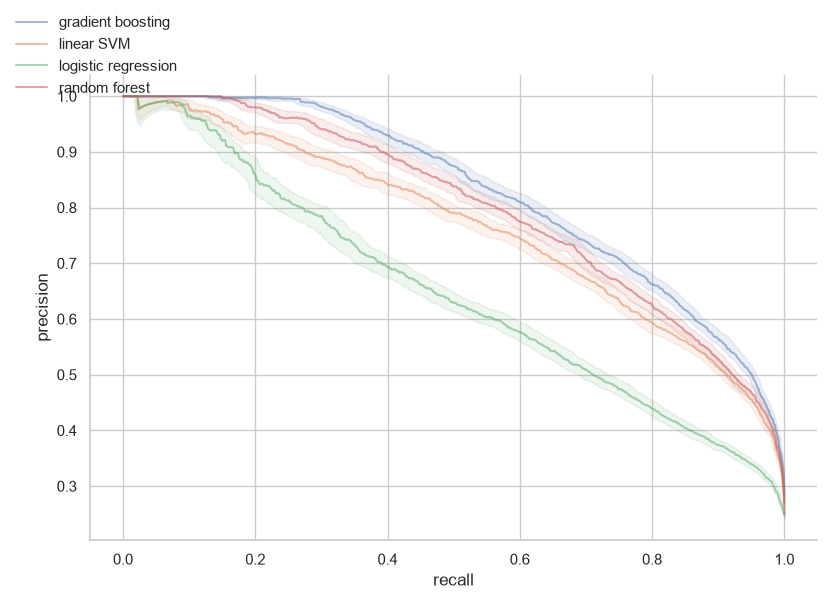

In [9]:
plot_pr(curves, hue="name", ci=0.90, recall_round=3, height=5.5, aspect=1.5)
plt.show()

Gradient boosting stays above the rest almost everywhere, and logistic
regression is clearly last. The middle two run close enough that the curves are
hard to separate by eye at this scale.

The bands widen to the right. At high recall the threshold is low, few rows
separate the models, and the metric is correspondingly less certain.

## Average precision, as a distribution

The band above is pointwise. For a single summary number with an interval,
take average precision per replica and read its quantiles.

In [10]:
resampled = average_precision(curves, by_model)
resampled = resampled[resampled["replica"] >= 0]

summary = (
    resampled.groupby("name")["average_precision"].quantile([0.05, 0.5, 0.95]).unstack()
)
summary.columns = ["5th percentile", "median", "95th percentile"]
summary.sort_values("median", ascending=False)

,5th percentile,median,95th percentile
name,,,
gradient boosting,0.816,0.825,0.835
random forest,0.790,0.800,0.808
linear SVM,0.753,0.765,0.775
logistic regression,0.634,0.646,0.660


All four intervals are disjoint: the 5th percentile of each model clears the
95th percentile of the next one down. Even the three-point gap between the
random forest and the SVM, which the curves above could not separate by eye,
survives resampling.

So the ranking is real, and this is what a conclusive comparison looks like.
Worth holding onto — the subgroups below will not look like this.

## The operating point

Metrics are not what ships; a threshold is. `at` finds the lowest threshold
whose precision clears a target, per replica, which turns a single operating
point into a distribution of them.

Note the threshold column mixes scales — the SVM's is a decision-function
value, the others are probabilities. That is what `replicas` hands back: the
number you would actually hard-code, on the scale you gave it.

In [11]:
operating = at(curves, by=by_model, precision=0.80)
operating = operating[operating["replica"] >= 0]

(
    operating.groupby("name")[["threshold", "recall"]]
    .quantile([0.05, 0.5, 0.95])
    .rename_axis(["name", "quantile"])
)

threshold  recall
name                quantile                   
gradient boosting   0.050         0.521   0.593
                    0.500         0.544   0.614
                    0.950         0.564   0.639
linear SVM          0.050         0.111   0.455
                    0.500         0.150   0.477
                    0.950         0.178   0.515
logistic regression 0.050         0.593   0.227
                    0.500         0.643   0.263
                    0.950         0.681   0.309
random forest       0.050         0.510   0.534
                    0.500         0.531   0.566
                    0.950         0.559   0.592

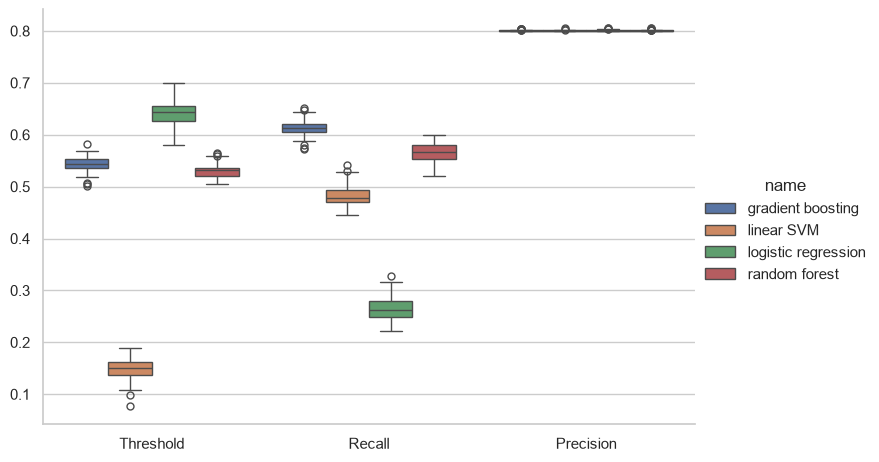

In [12]:
box_plot(
    operating,
    hue="name",
    values=("threshold", "recall", "precision"),
    height=5,
    aspect=1.5,
)
plt.show()

## Where the aggregate hides things

Every number so far is an average over 14,653 people. Averages can be steady
while the parts underneath them are not, so the same pipeline is worth running
one subgroup at a time.

This is ordinary disaggregated evaluation: same metric, same models, computed
separately per group. The only change is what goes in `by`.

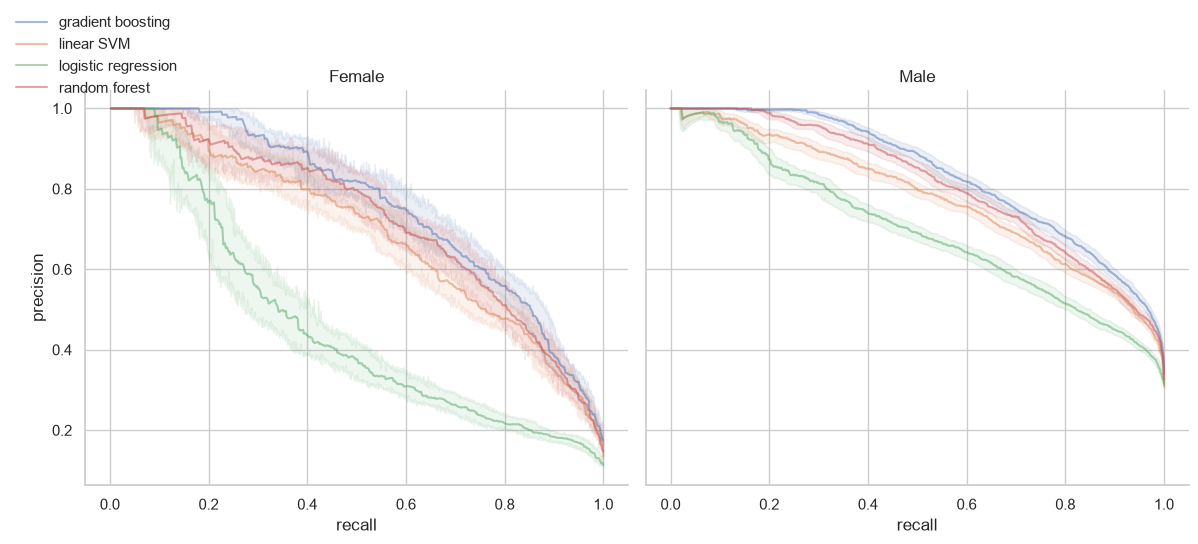

In [13]:
by_sex = ["name", "sex", "replica"]
curves_sex = calculate_pr(confusion_table(replicas_frame, by=by_sex), by=by_sex)

plot_pr(curves_sex, hue="name", col="sex", ci=0.90, recall_round=3, height=5, aspect=1.2)
plt.show()

The two panels are not the same picture. The curves sit lower for women and
the bands are wider: 544 of the 4,907 women in the test set earn above the
threshold, against 2,962 of the 9,746 men — an 11% positive rate against 30%.
A precision-recall curve is anchored to the base rate, and there is less signal
to work with on the left.

Splitting further makes the effect impossible to ignore.

In [14]:
sizes = (
    predictions[predictions["name"] == "gradient boosting"]
    .groupby(["sex", "age band"])
    .agg(rows=("positive", "size"), positives=("positive", "sum"))
)
sizes["positive rate"] = sizes["positives"] / sizes["rows"]
sizes.sort_values("positives")

rows  positives  positive rate
sex    age band                                
Female 17-24     1165          6          0.005
Male   17-24     1351         14          0.010
Female 55+        619         67          0.108
       45-54      769        123          0.160
       25-34     1254        140          0.112
       35-44     1100        208          0.189
Male   25-34     2496        499          0.200
       55+       1462        537          0.367
       45-54     1893        924          0.488
       35-44     2544        988          0.388

Look at the top of that table rather than the bottom. The 17-24 cells are not
small — 1,165 women and 1,351 men — but almost nobody in them earns above the
threshold, so they hold 6 and 14 positives. A precision-recall curve is built
out of positives, and six is not a measurement.

That is the distinction the row count alone would hide, and the band is the
only thing on the next figure that will say so.

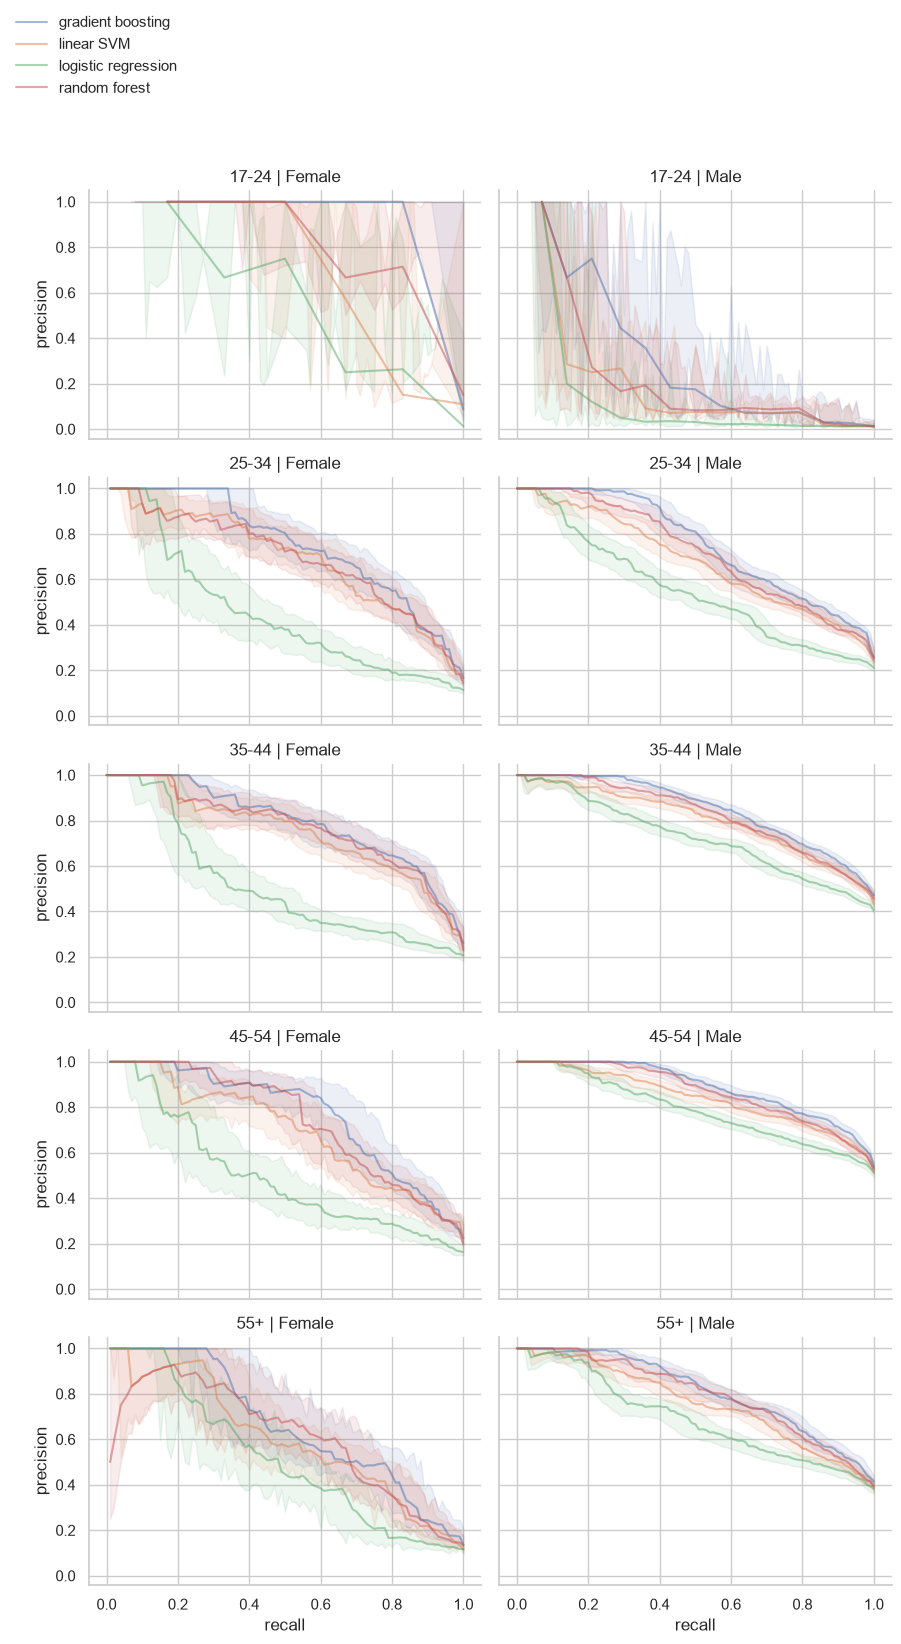

In [15]:
by_group = ["name", "sex", "age band", "replica"]
curves_group = calculate_pr(confusion_table(replicas_frame, by=by_group), by=by_group)

plot_pr(
    curves_group,
    hue="name",
    row="age band",
    col="sex",
    ci=0.90,
    recall_round=2,
    height=3.0,
    aspect=1.5,
)
plt.show()

Read the grid top to bottom, with the sexes side by side in each row. The
17-24 row is a mess of overlapping bands spanning most of its panels. By 45-54,
where hundreds of people clear the threshold, the bands are tight and the
models separate in the same order they did overall.

The point estimates in that first row are not wrong, exactly. They are just not
evidence. A report showing only the curves would invite a conclusion about model
behaviour in a group where the honest answer is that this test set cannot
tell.

The operating point makes the same case arithmetically. Asking for precision
≥ 0.80 in every subgroup, `at` returns nothing for a replica where no threshold
clears the target, so counting how often it resolves says something about the
subgroup.

Read the result carefully, though — it does not simply track the number of
rows.

In [16]:
resolved = (
    at(curves_group, by=by_group, precision=0.80)
    .query("replica >= 0")
    .groupby(["sex", "age band"])["replica"]
    .count()
    .div(len(models))
    .rename("mean replicas resolved per model (of 100)")
    .to_frame()
    .join(sizes[["rows", "positives"]])
    .sort_values("mean replicas resolved per model (of 100)")
)
resolved

mean replicas resolved per model (of 100)  rows  positives
sex    age band                                                            
Male   17-24                                        69.500  1351         14
Female 17-24                                        91.750  1165          6
       55+                                          99.750   619         67
       25-34                                       100.000  1254        140
       45-54                                       100.000   769        123
       35-44                                       100.000  1100        208
Male   25-34                                       100.000  2496        499
       35-44                                       100.000  2544        988
       45-54                                       100.000  1893        924
       55+                                         100.000  1462        537

Only the two 17-24 cells fail to resolve reliably, and the one with *fewer*
positives resolves more often, not less. That inversion is the tell. With six
positives a single true positive at the very top of the ranking already gives
precision 1.0, so the target is cleared trivially and the "operating point" is
one row deep. The 17-24 men, with fourteen, have enough data for 0.80 precision
to be a real constraint and not enough to satisfy it reliably.

Neither case is a measurement. The first is arithmetic on six people.

## Any statistic, not just these

Nothing above is special to precision and recall. The bootstrap output is a
normal DataFrame with a `replica` column, so any statistic you can compute per
group becomes a distribution with an interval — including ones `replicas` has
never heard of.

AUC, computed with scikit-learn on each replica:

In [17]:
auc = (
    replicas_frame[replicas_frame["replica"] >= 0]
    .groupby(["name", "replica"])[["positive", "prediction"]]
    .apply(lambda group: roc_auc_score(group["positive"], group["prediction"]))
    .rename("auc")
    .reset_index()
)

auc_summary = auc.groupby("name")["auc"].quantile([0.05, 0.5, 0.95]).unstack()
auc_summary.columns = ["5th percentile", "median", "95th percentile"]
auc_summary.sort_values("median", ascending=False)

,5th percentile,median,95th percentile
name,,,
gradient boosting,0.925,0.927,0.931
random forest,0.912,0.916,0.919
linear SVM,0.901,0.905,0.909
logistic regression,0.825,0.830,0.836


## What to take away

Every number in this notebook arrived with an interval, and the intervals are
what made the comparisons decidable. Over the full test set all four models
separate cleanly — including a three-point gap that the curves could not show
by eye — so the ranking can be reported as a result rather than a hunch.

Disaggregating showed the other half of it. The same evaluation that is
conclusive over 14,653 people says nothing at all about the youngest band,
where 1,165 women yield six positives — and without a band there is nothing on the
figure to tell you which case you are looking at.
The models do not become indistinguishable in those panels because the models
changed; they become indistinguishable because the evidence ran out.

The cost was one extra call. `bootstrap` runs on pandas, Polars, or Spark and
returns the same kind of frame it was given, so the same pipeline works on a
test set that does not fit in memory.

One caveat to keep. These are percentile-bootstrap intervals, and their
coverage guarantee is asymptotic. On a small sample the interval can be
narrower than its nominal level — which means the widest bands in that grid, in
the panels with three positives, are if anything *optimistic*.